<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Heart_disease/blob/main/Final_Defence_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb pandas numpy scikit-learn tensorflow matplotlib seaborn shap


In [ ]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Bidirectional, Dense, Dropout, Attention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam


# ***Download MIT-BIH Dataset***

In [ ]:
DATA_DIR = "mitdb"

if not os.path.exists(DATA_DIR):
    wfdb.dl_database('mitdb', dl_dir=DATA_DIR)

print("Dataset ready!")


Dataset ready!


# **Beat Extraction (Patient-aware)**

In [ ]:
WINDOW = 187
HALF = WINDOW // 2

label_map = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3
}

beats = []

records = sorted([f.split('.')[0] for f in os.listdir(DATA_DIR) if f.endswith('.dat')])

for record in records:
    try:
        signal, _ = wfdb.rdsamp(os.path.join(DATA_DIR, record))
        ann = wfdb.rdann(os.path.join(DATA_DIR, record), 'atr')
    except:
        continue

    ecg = signal[:, 0]

    for r, sym in zip(ann.sample, ann.symbol):
        if sym not in label_map:
            continue

        if r - HALF < 0 or r + HALF >= len(ecg):
            continue

        beat = ecg[r-HALF:r+HALF+1]
        beats.append([record] + beat.tolist() + [label_map[sym]])

columns = ["record_id"] + [f"f{i}" for i in range(WINDOW)] + ["label"]
df = pd.DataFrame(beats, columns=columns)

df.to_csv("mitbih_patient_level.csv", index=False)
print("Dataset created:", df.shape)


Dataset created: (101426, 189)


# **Patient-Independent Split**

In [ ]:
df = pd.read_csv("mitbih_patient_level.csv")

patients = df['record_id'].unique()

trainval_patients, test_patients = train_test_split(
    patients, test_size=0.20, random_state=42
)

train_patients, val_patients = train_test_split(
    trainval_patients, test_size=0.10, random_state=42
)

train_df = df[df['record_id'].isin(train_patients)]
val_df   = df[df['record_id'].isin(val_patients)]
test_df  = df[df['record_id'].isin(test_patients)]

print("No overlap ✔")


No overlap ✔


# **Prepare Data**

In [ ]:
def prepare(df):
    X = df.iloc[:, 1:-1].values
    y = df['label'].values.astype(int)

    # Normalize per beat
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    return X.reshape(-1, 187, 1), y

X_train, y_train = prepare(train_df)
X_val, y_val     = prepare(val_df)
X_test, y_test   = prepare(test_df)

print(X_train.shape, X_val.shape, X_test.shape)

(72737, 187, 1) (8245, 187, 1) (20444, 187, 1)


# ***Handle Class Imbalance***

In [ ]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.27984379809172055), 1: np.float64(8.1616921005386), 2: np.float64(3.5543881939014854), 3: np.float64(44.029661016949156)}


# **Focal Loss (Research-grade)**

In [ ]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        return alpha * tf.pow(1. - pt, gamma) * ce
    return loss

# **Build CNN + BiLSTM + Attention Model**

In [ ]:
inputs = Input(shape=(187,1))

x = Conv1D(32, 5, activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(64, 5, activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(128, 3, activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

# BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# Attention
attn = Attention()([x, x])

x = GlobalAveragePooling1D()(attn)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(0.0005),
    loss=focal_loss(),
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 183, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 183, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 91, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 87, 64)    │     10,304 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 87, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 43, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 41, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 41, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 20, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 20, 128)   │     98,816 │ max_pooling1d_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 20, 128)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 151,940 (593.52 KB)

 Trainable params: 151,492 (591.77 KB)

 Non-trainable params: 448 (1.75 KB)

# **Train Model**

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 70s 62ms/step - accuracy: 0.9363 - loss: 0.0157 - val_accuracy: 0.7126 - val_loss: 0.1677
Epoch 2/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 69s 61ms/step - accuracy: 0.9377 - loss: 0.0148 - val_accuracy: 0.7476 - val_loss: 0.2824
Epoch 3/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 69s 61ms/step - accuracy: 0.9473 - loss: 0.0116 - val_accuracy: 0.7143 - val_loss: 0.4051
Epoch 4/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 71s 62ms/step - accuracy: 0.9514 - loss: 0.0107 - val_accuracy: 0.7535 - val_loss: 0.2727
Epoch 5/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 69s 61ms/step - accuracy: 0.9549 - loss: 0.0098 - val_accuracy: 0.6877 - val_loss: 0.3433
Epoch 6/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.9636 - loss: 0.0069 - val_accuracy: 0.7419 - val_loss: 0.3841
Epoch 7/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 69s 60ms/step - accuracy: 0.9661 - loss: 0.0076 - val_accuracy: 0.7510 - val_loss: 0.3896
Epoch 8/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9676 -

# **Save Model**

In [ ]:
model.save("ecg_cnn_bilstm_attention.keras")

# **Evaluation**

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

639/639 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.56      0.71     19217
           1       0.04      0.30      0.07       411
           2       0.21      0.93      0.34       800
           3       0.00      0.25      0.00        16

    accuracy                           0.57     20444
   macro avg       0.31      0.51      0.28     20444
weighted avg       0.93      0.57      0.68     20444

Confusion Matrix:
[[10743  2878  2796  2800]
 [  184   124    57    46]
 [   15    10   744    31]
 [    6     2     4     4]]


# **Confusion Matrix Plot**

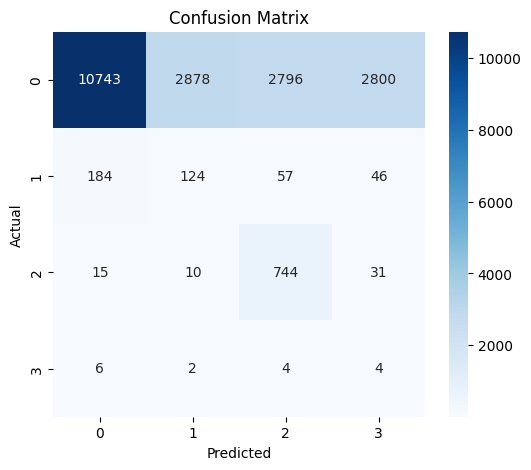

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **ROC-AUC (Multi-class)**

In [ ]:
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=4)

auc = roc_auc_score(y_test_onehot, y_pred_probs, multi_class='ovr')
print("ROC-AUC:", auc)


ROC-AUC: 0.7579700169178335


### Model Performance Evaluation on Test Data

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

639/639 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.56      0.71     19217
           1       0.04      0.30      0.07       411
           2       0.21      0.93      0.34       800
           3       0.00      0.25      0.00        16

    accuracy                           0.57     20444
   macro avg       0.31      0.51      0.28     20444
weighted avg       0.93      0.57      0.68     20444

Confusion Matrix:
[[10743  2878  2796  2800]
 [  184   124    57    46]
 [   15    10   744    31]
 [    6     2     4     4]]


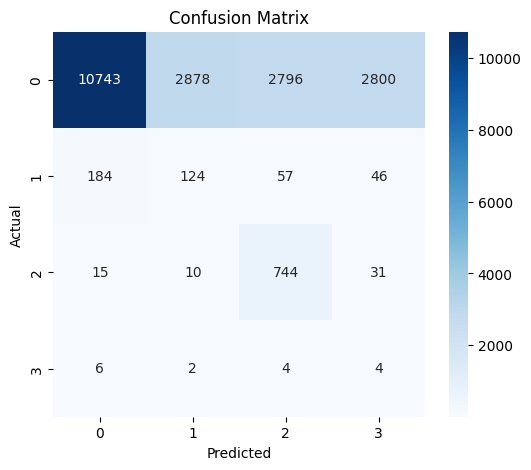

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=4)

auc = roc_auc_score(y_test_onehot, y_pred_probs, multi_class='ovr')
print("ROC-AUC:", auc)

ROC-AUC: 0.7579700169178335


In [ ]:
!pip uninstall shap -y
!pip install shap==0.41.0
import shap

explainer = shap.DeepExplainer(model, X_train[:100])
shap_values = explainer.shap_values(X_test[:10])

shap.summary_plot(shap_values, X_test[:10])

Found existing installation: shap 0.41.0
Uninstalling shap-0.41.0:
  Successfully uninstalled shap-0.41.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.6 MB/s eta 0:00:00


ImportError: cannot import name 'AdditiveExplainer' from 'shap.explainers._additive' (/usr/local/lib/python3.12/dist-packages/shap/explainers/_additive.py)

### Using SHAP KernelExplainer

In [ ]:
import shap

# Define a prediction function that takes a numpy array and returns probabilities
def predict_proba(X):
    # The model expects a 3D input (samples, timesteps, features)
    # KernelExplainer will pass 2D input (samples, timesteps), so we need to add the feature dimension back
    return model.predict(X.reshape(X.shape[0], X.shape[1], 1))

# Use a small subset of the training data as the background dataset for KernelExplainer
# KernelExplainer can be computationally intensive, so using a smaller background is practical.
# Reshape background data to 2D for KernelExplainer
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)].squeeze(-1)

# Initialize KernelExplainer
explainer_kernel = shap.KernelExplainer(predict_proba, background)

# Select a small number of test samples to explain (KernelExplainer can be slow)
# Reshape test sample data to 2D for KernelExplainer
X_test_sample = X_test[:10].squeeze(-1)

# Compute SHAP values
print("Computing SHAP values with KernelExplainer... This may take some time.")
shap_values_kernel = explainer_kernel.shap_values(X_test_sample)

In [ ]:
# Visualize the SHAP values
# For multi-output models, shap_values will be a list of arrays, one for each output.
# We can plot the SHAP values for a specific class (e.g., class 0).
# shap.summary_plot(shap_values_kernel[0], X_test_sample, plot_type="bar", feature_names=[f'feature_{i}' for i in range(X_test_sample.shape[1])])

# A better visualization for multi-class would be a summary plot for all classes
shap.summary_plot(shap_values_kernel, X_test_sample, plot_type="bar")

# **Positional Encoding**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class PositionalEncoding(Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(sequence_length, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / tf.pow(10000., (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return pos * angles

    def positional_encoding(self, length, d_model):
        positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
        dims = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]

        angle_rads = self.get_angles(positions, dims, d_model)

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])

        pos_encoding = tf.concat([sines, cosines], axis=-1)
        return pos_encoding[tf.newaxis, ...]

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]


# **Transformer Encoder Block**

In [ ]:
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention

def transformer_encoder(x, head_size, num_heads, ff_dim, dropout=0.1):

    # Self-attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size
    )(x, x)

    attn_output = Dropout(dropout)(attn_output)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)

    # Feed Forward
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dense(x.shape[-1])(ff)

    ff = Dropout(dropout)(ff)
    x = LayerNormalization(epsilon=1e-6)(x + ff)

    return x


# **Build Transformer ECG Model**

In [ ]:
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer_model():
    inputs = Input(shape=(187,1))

    # Project to higher dimension
    x = Dense(64)(inputs)

    # Add positional encoding
    x = PositionalEncoding(187, 64)(x)

    # Stack Transformer blocks
    for _ in range(3):
        x = transformer_encoder(
            x,
            head_size=64,
            num_heads=4,
            ff_dim=128,
            dropout=0.1
        )

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(4, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_transformer_model()
model.summary()


# **Compile (Use Focal Loss)**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss=focal_loss(),
    metrics=['accuracy']
)


# **Train**

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    verbose=1
)